In [ ]:
import json
import re
import matplotlib.pyplot as plt
from collections import defaultdict

In [38]:
# METRICS_PATH = "output_DVIS_Online_R50_YTVIS22/metrics.json"
METRICS_PATH = "output_DVIS_Online_SwinL_YTVIS22/metrics.json"
# METRICS_PATH = "output_DVIS_Online_RFDETR_YTVIS22/metrics.json"

data = defaultdict(list)
iters = []
with open(METRICS_PATH) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        d = json.loads(line)
        iters.append(d["iteration"])
        for k, v in d.items():
            if k.startswith("loss") or k == "total_loss":
                data[k].append(v)

print(f"Parsed {len(iters)} iterations")
print(f"Keys: {sorted(data.keys())}")

Parsed 458 iterations
Keys: ['loss_ce', 'loss_ce_0', 'loss_ce_1', 'loss_ce_2', 'loss_ce_3', 'loss_ce_4', 'loss_dice', 'loss_dice_0', 'loss_dice_1', 'loss_dice_2', 'loss_dice_3', 'loss_dice_4', 'loss_mask', 'loss_mask_0', 'loss_mask_1', 'loss_mask_2', 'loss_mask_3', 'loss_mask_4', 'total_loss']


In [39]:
# Separate final-layer vs per-layer losses
final_keys = sorted(k for k in data if not re.search(r"_\d+$", k))
per_layer_keys = sorted(k for k in data if re.search(r"_\d+$", k))

# Group per-layer by loss type (e.g. loss_ce_0..4 -> loss_ce)
loss_types = sorted(set(re.sub(r"_\d+$", "", k) for k in per_layer_keys))

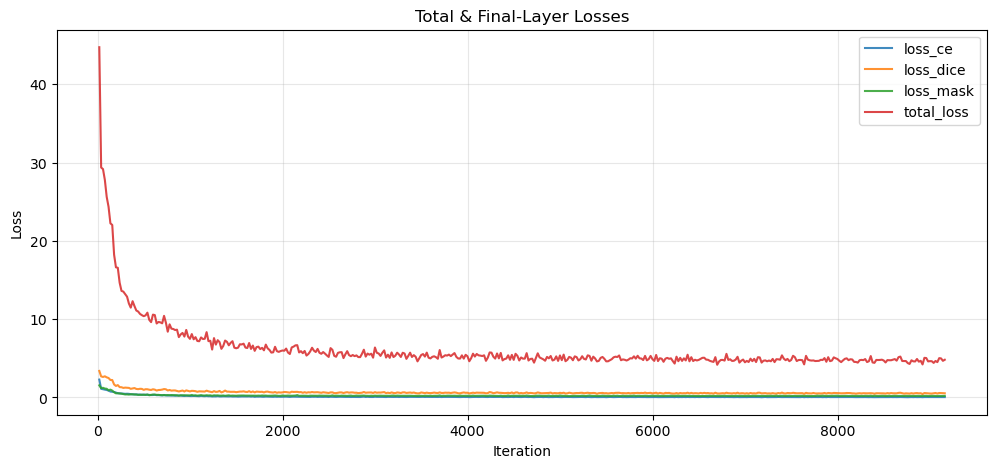

In [40]:
# Plot total + final-layer losses
fig, ax = plt.subplots(figsize=(12, 5))
for key in final_keys:
    ax.plot(iters[:len(data[key])], data[key], label=key, alpha=0.85)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Total & Final-Layer Losses")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

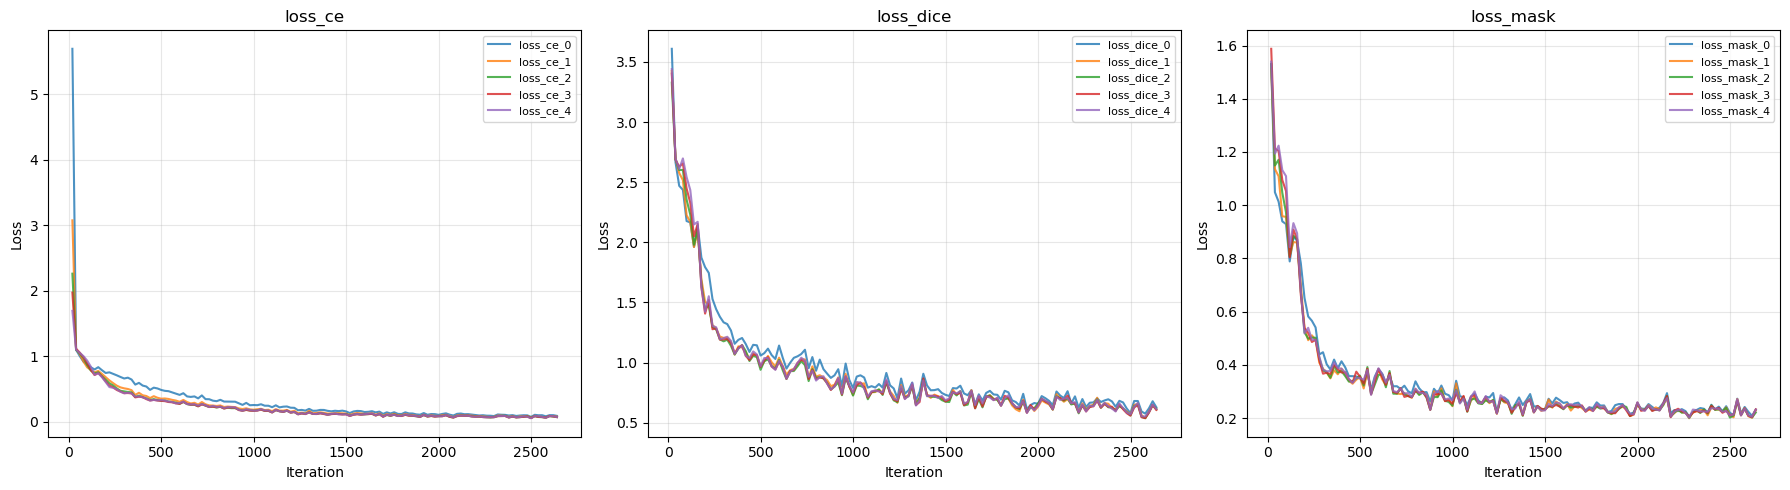

In [21]:
# Plot per-layer losses, one subplot per loss type
fig, axes = plt.subplots(1, len(loss_types), figsize=(6 * len(loss_types), 5))
if len(loss_types) == 1:
    axes = [axes]
for ax, lt in zip(axes, loss_types):
    keys = sorted(k for k in per_layer_keys if k.startswith(lt))
    for key in keys:
        ax.plot(iters[:len(data[key])], data[key], label=key, alpha=0.8)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title(lt)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

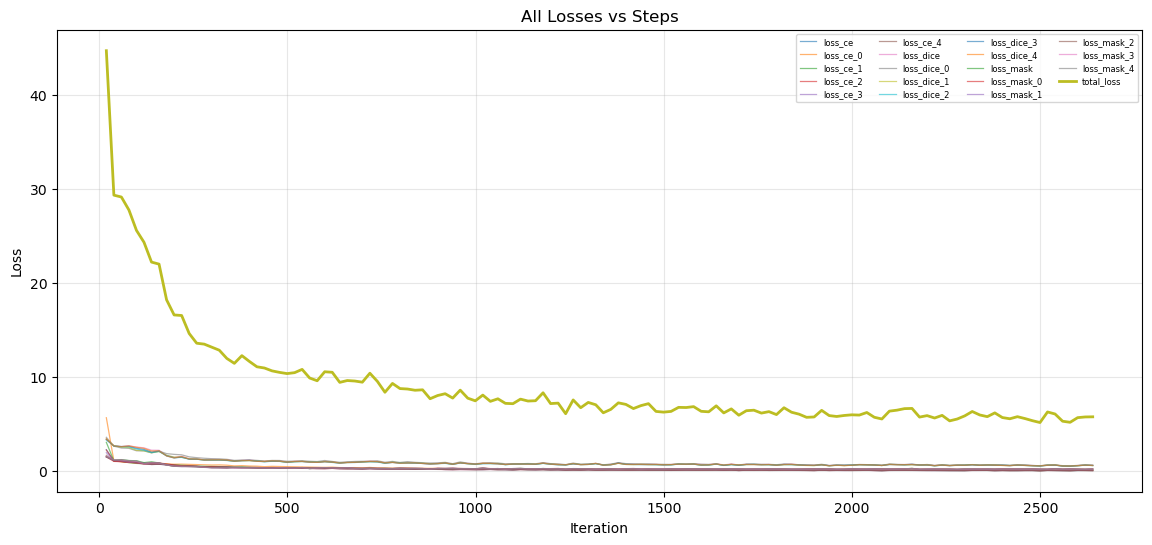

In [22]:
# Plot ALL losses on one figure
fig, ax = plt.subplots(figsize=(14, 6))
all_keys = sorted(data.keys())
for key in all_keys:
    lw = 2.0 if key == "total_loss" else 0.9
    alpha = 1.0 if key == "total_loss" else 0.6
    ax.plot(iters[:len(data[key])], data[key], label=key, linewidth=lw, alpha=alpha)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("All Losses vs Steps")
ax.legend(fontsize=6, ncol=4, loc="upper right")
ax.grid(True, alpha=0.3)
plt.show()